# Figure 4

GF output

In [2]:
library(tidyverse)
library(cowplot)
library(data.table)
require(gradientForest)


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attache Paket: ‘cowplot’


Das folgende Objekt ist maskiert ‘package:lubridate’:

    stamp



Attache Paket: ‘data.table’


Die folgenden Objekte sind maskiert von ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
 

In [3]:
phyto_counts <- readRDS("../1 - data/processed/PhytoplanktonInterpolatedCounts_above45m.RDS")
phyto_counts = phyto_counts[complete.cases(phyto_counts$counts),]

Warning message in gzfile(file, "rb"):
“kann komprimierte Datei '../1 - data/processed/PhytoplanktonInterpolatedCounts_above45m.RDS' nicht öffnen. Grund evtl. 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): kann Verbindung nicht öffnen


In [3]:
phyto_counts[phyto_counts$ScientificName_corrected=="nanoflagellates",]$Genus <- "Nanoflagellates"

In [4]:
phyto_counts[phyto_counts$Genus=="Pseudo-nitzschia",]$Genus <- "Pseudo.nitzschia"

In [5]:
CARIACO <- readRDS("../1 - data/processed/CARIACO_EnvData_combined.rds")

In [6]:
extractMatrixFix <- function(env_factors){

    ds_genus <- phyto_counts %>% 
            #mutate(CorrectedAphiaID = coalesce(CorrectedAphiaID,AphiaID)) %>%
            filter(TaxonRank == "Genus" | TaxonRank == "Species")%>% #| TaxonRank == "Group") %>% #, FuncGroup=="Dinoflagellata") %>%
            #filter(TaxonRank == "Species") %>%    
            group_by(Genus, date) %>%
            summarise(Total = sum(counts))  %>%
            arrange(desc(date))
        #tail(ds_genus)
    
    
    Mesh_genus <- pivot_wider(ds_genus, names_from = Genus, values_from = Total, values_fn = sum, values_fill = 0)
    Mesh_genus$time_month =format(Mesh_genus$date, format="%m-%Y")
    new_Mesh_genus = Mesh_genus %>% select(-date)

    Env_dat <- CARIACO %>% 
            select("time_month", all_of(env_factors))

    
    CARIACO_dat_joined <- list(Env_dat, 
                           new_Mesh_genus) %>% 
          reduce(full_join, by = c("time_month")) %>% select(-time_month)

    
    Comp_Matrix <- CARIACO_dat_joined[complete.cases(CARIACO_dat_joined),]
    
    Matrix_Env <- Comp_Matrix %>% select(all_of(env_factors))

    Matrix_Genus <- Comp_Matrix %>% select(-all_of(env_factors))
    
    return(list(Matrix_Env, Matrix_Genus))
}

In [7]:
names(CARIACO)

[1] "tauoc"                             "sst"                              
  [3] "sp"                                "u10"                              
  [5] "v10"                               "lsm"                              
  [7] "si10"                              "ewss"                             
  [9] "e"                                 "ro"                               
 [11] "tp"                                "mtpr"                             
 [13] "time_month"                        "u10_lag1"                         
 [15] "u10_lag2"                          "u10_lag3"                         
 [17] "u10_lag4"                          "u10_lag5"                         
 [19] "u10_lag6"                          "O2_umol_kg"                       
 [21] "O2_ml_L"                           "NO3_UDO"                          
 [23] "PO4_UDO"                           "SiO4_UDO"                         
 [25] "NH4_USF"                           "NO2_USF"                          
 [27] "NO3_NO2_USF"                       "NO3_USF"                          
 [29] "PO4_USF"                           "SiO4_USF"                         
 [31] "NO3_merged"                        "PO4_merged"                       
 [33] "SiO4_merged"                       "pH_corrected"                     
 [35] "Salinity_bottles"                  "Temperature"                      
 [37] "Sigma_t"                           "PrimaryProductivity"              
 [39] "Chlorophyll"                       "Phaeopigments"                    
 [41] "NO3_merged_lag1"                   "NO3_merged_lag2"                  
 [43] "NO3_merged_lag3"                   "PO4_merged_lag1"                  
 [45] "PO4_merged_lag2"                   "PO4_merged_lag3"                  
 [47] "SiO4_merged_lag1"                  "SiO4_merged_lag2"                 
 [49] "SiO4_merged_lag3"                  "Temperature_lag1"                 
 [51] "Temperature_lag2"                  "Temperature_lag3"                 
 [53] "Salinity_bottles_lag1"             "Salinity_bottles_lag2"            
 [55] "Salinity_bottles_lag3"             "O2_umol_kg_above50m"              
 [57] "O2_ml_L_above50m"                  "NO3_UDO_above50m"                 
 [59] "PO4_UDO_above50m"                  "SiO4_UDO_above50m"                
 [61] "NH4_USF_above50m"                  "NO2_USF_above50m"                 
 [63] "NO3_NO2_USF_above50m"              "NO3_USF_above50m"                 
 [65] "PO4_USF_above50m"                  "SiO4_USF_above50m"                
 [67] "NO3_merged_above50m"               "PO4_merged_above50m"              
 [69] "SiO4_merged_above50m"              "pH_corrected_above50m"            
 [71] "Salinity_bottles_above50m"         "Temperature_above50m"             
 [73] "Sigma_t_above50m"                  "PrimaryProductivity_above50m"     
 [75] "Chlorophyll_above50m"              "Phaeopigments_above50m"           
 [77] "O2_umol_kg_below50m"               "O2_ml_L_below50m"                 
 [79] "NO3_UDO_below50m"                  "PO4_UDO_below50m"                 
 [81] "SiO4_UDO_below50m"                 "NH4_USF_below50m"                 
 [83] "NO2_USF_below50m"                  "NO3_NO2_USF_below50m"             
 [85] "NO3_USF_below50m"                  "PO4_USF_below50m"                 
 [87] "SiO4_USF_below50m"                 "NO3_merged_below50m"              
 [89] "PO4_merged_below50m"               "SiO4_merged_below50m"             
 [91] "pH_corrected_below50m"             "Salinity_bottles_below50m"        
 [93] "Temperature_below50m"              "Sigma_t_below50m"                 
 [95] "PrimaryProductivity_below50m"      "Chlorophyll_below50m"             
 [97] "Phaeopigments_below50m"            "source"                           
 [99] "Pras"                              "Lut"                              
[101] "Fuco"                              "Perid"                            
[103] "Allo"            

# Variable Selection Runs

In [8]:
GF_env_factors_NO3 = c("NO3_merged", "NO3_merged_lag1", "NO3_merged_lag2", "NO3_merged_lag3")

GF_env_factors_PO4 = c("PO4_merged", "PO4_merged_lag1", "PO4_merged_lag2", "PO4_merged_lag3")

GF_env_factors_SiO4 = c("SiO4_merged", "SiO4_merged_lag1", "SiO4_merged_lag2", "SiO4_merged_lag3")

GF_env_factors_Temperature = c("Temperature", "Temperature_lag1", "Temperature_lag2", "Temperature_lag3")

GF_env_factors_Isotherm_21 = c("Isotherm_21", "Isotherm_21_lag1", "Isotherm_21_lag2", "Isotherm_21_lag3")

GF_env_factors_Salinity_bottles = c("Salinity_bottles", "Salinity_bottles_lag1", "Salinity_bottles_lag2", "Salinity_bottles_lag3")

GF_env_factors_u10 = c("u10", "u10_lag1", "u10_lag2", "u10_lag3", "u10_lag4", "u10_lag4", "u10_lag5", "u10_lag6")

GF_env_factors_AMO = c("AMO", "AMO_lag1", "AMO_lag2", "AMO_lag3", "AMO_lag4", "AMO_lag4", "AMO_lag5", "AMO_lag6")

GF_env_factors_MEIv2 = c("MEIv2", "MEIv2_lag1", "MEIv2_lag2", "MEIv2_lag3", "MEIv2_lag4", "MEIv2_lag4", "MEIv2_lag5", "MEIv2_lag6")

In [9]:
runGFmodel <- function(env_factors){
    # function to extract data and run GF model
    data <- extractMatrixFix(env_factors)

    envGF <- data[[1]]
    specGF <- data[[2]]

    mo5_specGF<- specGF %>% select_if(colSums(. > 0) > 10)
    colnames(mo5_specGF) <- make.names(colnames(mo5_specGF))

    nSites <- dim(mo5_specGF)[1]
    nSpecs <- dim(mo5_specGF)[2]
    lev <- floor(log2(nSites * 0.368/2))
    
    log_specGF <- log1p(mo5_specGF*100)

    gf <- gradientForest(cbind(envGF, log_specGF),
                     predictor.vars=colnames(envGF),
                     response.vars=colnames(mo5_specGF),
                     ntree=500,
                     transform=NULL,
                     compact=T,
                     trace=T,
                     nbin=201,
                     maxLevel=lev,
                     corr.threshold=0.5)
    return(gf)
}

In [33]:
GF_output_NO3 <- runGFmodel(GF_env_factors_NO3)

GF_output_PO4 <- runGFmodel(GF_env_factors_PO4)

GF_output_SiO4 <- runGFmodel(GF_env_factors_SiO4)

GF_output_Temperature <- runGFmodel(GF_env_factors_Temperature)

GF_output_Isotherm_21 <- runGFmodel(GF_env_factors_Isotherm_21)

GF_output_Salinity_bottles <- runGFmodel(GF_env_factors_Salinity_bottles)

GF_output_u10 <- runGFmodel(GF_env_factors_u10)

GF_output_AMO <- runGFmodel(GF_env_factors_AMO)

GF_output_MEIv2 <- runGFmodel(GF_env_factors_MEIv2)

`summarise()` has grouped output by 'Genus'. You can override using the
`.groups` argument.


Calculating forests for 82 species
...............................................................................
...

`summarise()` has grouped output by 'Genus'. You can override using the
`.groups` argument.


Calculating forests for 88 species
...............................................................................
.........

`summarise()` has grouped output by 'Genus'. You can override using the
`.groups` argument.


...

Calculating forests for 91 species
...............................................................................
............

`summarise()` has grouped output by 'Genus'. You can override using the
`.groups` argument.


Calculating forests for 91 species
...............................................................................
............

`summarise()` has grouped output by 'Genus'. You can override using the
`.groups` argument.


Calculating forests for 91 species
...............................................................................
............

In [83]:
NO3_lags = as.numeric(importance(GF_output_NO3, sort=FALSE))
PO4_lags = as.numeric(importance(GF_output_PO4, sort=FALSE))
SiO4_lags = as.numeric(importance(GF_output_SiO4, sort=FALSE))
Temperature_lags = as.numeric(importance(GF_output_Temperature, sort=FALSE))
Isotherm_21_lags = as.numeric(importance(GF_output_Isotherm_21, sort=FALSE))
Salinity_bottles_lags = as.numeric(importance(GF_output_Salinity_bottles, sort=FALSE))
u10_lags = as.numeric(importance(GF_output_u10, sort=FALSE))
AMO_lags = as.numeric(importance(GF_output_AMO, sort=FALSE))
MEIv2_lags = as.numeric(importance(GF_output_MEIv2, sort=FALSE))

In [84]:
sq <- seq(7)
variable_selection = data.frame("lag" = 0:6,"NO3"=NO3_lags[sq], 
           "PO4"=PO4_lags[sq], 
           "SiO4"=SiO4_lags[sq], 
           "Temperature"=Temperature_lags[sq],               
           "Isotherm_21"=Isotherm_21_lags[sq], 
           "Salinity_bottles"=Salinity_bottles_lags[sq], 
           "u10"=u10_lags[sq],
           "AMO"=AMO_lags[sq],
           "MEIv2"=MEIv2_lags[sq])

In [106]:
library("kableExtra")
options(scipen=3)

variable_selection %>%
    kbl("latex", booktabs = T, digits=3,
        caption="Individual Gradient Forest model runs for each variable and the corresponding time lags. 
        For in-situ variables, for which no coverage extends over the time series, 
        we tested all measurements up to a lag of 3 months. 
        For climate variables we tested up to a lag of 6 months. 
        Time lag with maximum importance per variable are highlighted in bold and chosen for the final model run.") #%>%

    #cell_spec(2, bold = ifelse(. > 0.3, TRUE, FALSE)) 


\begin{table}

\caption{Individual Gradient Forest model runs for each variable and the correpsonding time lags. 
        For in-situ variables, for which no coverage extends over the time series, 
        we tested all measuerments up to a lag of 3 months. 
        For climate variables we tested up to a lag of 6 months. 
        Maximum importance per variable are hightlighed in bold. 
        If an earlier time lag scored very closely (less than 5 percent) to the maximum, it was chosen instead. 
        Chosen time lags are marked with an asterisk.}
\centering
\begin{tabular}[t]{rrrrrrrrrr}
\toprule
lag & NO3 & PO4 & SiO4 & Temperature & Isotherm\_21 & Salinity\_bottles & u10 & AMO & MEIv2\\
\midrule
0 & 0.038 & 0.038 & 0.034 & 0.071 & 0.028 & 0.007 & 0.004 & 0.016 & 0.015\\
1 & 0.017 & 0.011 & 0.015 & 0.002 & 0.002 & 0.004 & 0.010 & 0.014 & 0.018\\
2 & 0.022 & 0.008 & 0.013 & 0.006 & 0.008 & 0.011 & 0.009 & 0.030 & 0.019\\
3 & 0.016 & 0.007 & 0.004 & 0.005 & 0.007 & 0.010 & 0.007 &

# FINAL MODEL RUN

In [10]:
DATAAAA <- CARIACO[c("GenusRichness","Shannon_gen","Pielou_gen", "u10_lag2", "NO3_merged",
                              "PO4_merged", "SiO4_merged",
                               "Salinity_bottles_lag2", "Temperature", "Isotherm_21",
                               "AMO_lag2", 
                               "MEIv2_lag4")]

In [12]:
Comp_Matrix <- DATAAAA[complete.cases(DATAAAA),]

Matrix_Env <- Comp_Matrix %>% select(-all_of(c("GenusRichness","Shannon_gen","Pielou_gen")))

Matrix_Genus <- Comp_Matrix %>% select(all_of(c("GenusRichness","Shannon_gen","Pielou_gen")))

In [67]:
Matrix_Genus

,GenusRichness,Shannon_gen,Pielou_gen
,<int>,<dbl>,<dbl>
674,45,2.4558319,0.6451404
676,38,1.8096693,0.4974918
677,43,2.4695404,0.6565831
678,35,1.9556124,0.5500481
679,40,2.2063044,0.5980961
680,35,0.6771182,0.1904506
681,34,1.7067574,0.4839997
682,14,0.5152322,0.1952334
683,34,2.3464976,0.6654162


In [13]:
nSites <- dim(Matrix_Genus)[1]
nSpecs <- dim(Matrix_Genus)[2]
lev <- floor(log2(nSites * 0.368/2))
lev

[1] 5

In [14]:
print(nSites)
print(nSpecs)

[1] 191
[1] 3


In [17]:
gf <- gradientForest(cbind(Matrix_Env, Matrix_Genus),
                     predictor.vars=colnames(Matrix_Env),
                     response.vars=colnames(Matrix_Genus),
                     ntree=1500,
                     transform=NULL,
                     compact=T,
                     trace=T,
                     nbin=201,
                     maxLevel=lev,
                     corr.threshold=0.5)
gf

Calculating forests for 3 species
...

A forest of 1500 regression trees for each of 1 species

Call:

gradientForest(data = cbind(Matrix_Env, Matrix_Genus), predictor.vars = colnames(Matrix_Env), 
    response.vars = colnames(Matrix_Genus), ntree = 1500, transform = NULL, 
    maxLevel = lev, corr.threshold = 0.5, compact = T, nbin = 201, 
    trace = T)



Important variables:
[1] MEIv2_lag4  NO3_merged  AMO_lag2    Isotherm_21 SiO4_merged


In [6]:
GF_env_factors_FULL = c("u10_lag2", "NO3_merged",
                              "PO4_merged", "SiO4_merged",
                               "Salinity_bottles_lag2", "Temperature", "Isotherm_21",
                               "AMO_lag2", 
                               "MEIv2_lag4")

In [12]:
GF_outputs <- extractMatrixFix(GF_env_factors_FULL)

`summarise()` has grouped output by 'Genus'. You can override using the
`.groups` argument.


In [13]:
envGF <- GF_outputs[[1]]
specGF <- GF_outputs[[2]]

In [14]:
mo5_specGF<- specGF %>% select_if(colSums(. > 0) > 10)

In [15]:
colnames(mo5_specGF) <- make.names(colnames(mo5_specGF))

In [16]:
colnames(mo5_specGF)
colnames(envGF)

[1] "Akashiwo"          "Alexandrium"       "Amphidinium"      
 [4] "Amphora"           "Anabaena"          "Asterionella"     
 [7] "Asterionellopsis"  "Bacteriastrum"     "Bellerochea"      
[10] "Blepharocysta"     "Calcidiscus"       "Calciopappus"     
[13] "Calciosolenia"     "Calyptrosphaera"   "Cerataulina"      
[16] "Chaetoceros"       "Climacodium"       "Coccolithus"      
[19] "Cochlodinium"      "Corethron"         "Coscinodiscus"    
[22] "Cyclolithella"     "Cylindrotheca"     "Cystodinium"      
[25] "Dactyliosolen"     "Detonula"          "Dictyocha"        
[28] "Dinophysis"        "Diplopsalis"       "Emiliana"         
[31] "Eucampia"          "Eutreptia"         "Eutreptiella"     
[34] "Glenodinium"       "Gonyaulax"         "Grammatophora"    
[37] "Guinardia"         "Gymnodinium"       "Gyrodinium"       
[40] "Haslea"            "Helicotheca"       "Hemiaulus"        
[43] "Heterocapsa"       "Johannesbaptistia" "Lauderia"         
[46] "Leptocylindrus"    "Lingulodinium"     "Lioloma"          
[49] "Lyngbya"           "Mesodinium"        "Mesoporos"        
[52] "Michaelsarsia"     "Navicula"          "Nitzschia"        
[55] "Noctiluca"         "Odontella"         "Ophiaster"        
[58] "Ornithocercus"     "Oxytoxum"          "Phalacroma"       
[61] "Pinnularia"        "Pinnunavis"        "Planktoniella"    
[64] "Pleurosigma"       "Podolampas"        "Proboscia"        
[67] "Pronoctiluca"      "Prorocentrum"      "Protoperidinium"  
[70] "Pseudo.nitzschia"  "Pyrocystis"        "Pyrophacus"       
[73] "Rhizosolenia"      "Scrippsiella"      "Skeletonema"      
[76] "Sphaerodinium"     "Stephanopyxis"     "Sundstroemia"     
[79] "Synechococcus"     "Syracosphaera"     "Tabularia"        
[82] "Thalassionema"     "Thalassiosira"     "Triadinium"       
[85] "Trichodesmium"     "Tripos"            "Tryblionella"     
[88] "Umbellosphaera"    "Umbilicosphaera"

[1] "u10_lag2"              "NO3_merged"            "PO4_merged"           
[4] "SiO4_merged"           "Salinity_bottles_lag1" "Temperature"          
[7] "Isotherm_21"           "AMO_lag2"              "MEIv2_lag4"

In [17]:
nSites <- dim(mo5_specGF)[1]
nSpecs <- dim(mo5_specGF)[2]
lev <- floor(log2(nSites * 0.368/2))
lev

[1] 5

In [18]:
print(nSites)
print(nSpecs)

[1] 191
[1] 89


In [19]:
log_specGF <- log1p(mo5_specGF*100)

In [20]:
gf <- gradientForest(cbind(envGF, log_specGF),
                     predictor.vars=colnames(envGF),
                     response.vars=colnames(mo5_specGF),
                     ntree=1500,
                     transform=NULL,
                     compact=T,
                     trace=T,
                     nbin=201,
                     maxLevel=lev,
                     corr.threshold=0.5)
gf

Calculating forests for 89 species
...............................................................................
..........

A forest of 1500 regression trees for each of 43 species

Call:

gradientForest(data = cbind(envGF, log_specGF), predictor.vars = colnames(envGF), 
    response.vars = colnames(mo5_specGF), ntree = 1500, transform = NULL, 
    maxLevel = lev, corr.threshold = 0.5, compact = T, nbin = 201, 
    trace = T)



Important variables:
[1] AMO_lag2    MEIv2_lag4  NO3_merged  Temperature SiO4_merged


In [22]:
gf$imp.rsq

,Akashiwo,Amphidinium,Amphora,Asterionellopsis,Bacteriastrum,Calciosolenia,Cerataulina,Chaetoceros,Cochlodinium,Coscinodiscus,⋯,Prorocentrum,Pseudo.nitzschia,Pyrophacus,Rhizosolenia,Skeletonema,Sundstroemia,Synechococcus,Thalassionema,Thalassiosira,Trichodesmium
u10_lag2,0.0113052421,0.0000000000,4.048851e-03,0.0016148959,0.005649048,0.0028215060,0.0009826952,0.014995453,0.001130473,0.001202304,⋯,0.003080598,0.004877005,0.0000000000,0.009580905,0.003596535,0.008494199,0.000000000,0.003202263,0.013187384,0.0079910457
NO3_merged,0.0004126801,0.0007111674,1.716454e-02,0.0056889956,0.038206988,0.0095984136,0.0061206401,0.045074385,0.004397657,0.006686120,⋯,0.017714587,0.028037344,0.0075731748,0.019906285,0.043873319,0.021194006,0.012918955,0.021896588,0.024068671,0.0079880810
PO4_merged,0.0019064363,0.0024417956,2.399905e-03,0.0018986816,0.017948089,0.0055827884,0.0000000000,0.006051362,0.002174204,0.004702505,⋯,0.002697420,0.003192723,0.0034924181,0.015273573,0.010735883,0.006023013,0.017616749,0.000000000,0.019207383,0.0024399202
SiO4_merged,0.0004755290,0.0026924209,2.144406e-06,0.0004549079,0.011881657,0.0002566725,0.0016469555,0.029322729,0.001781342,0.032464901,⋯,0.010376645,0.014274788,0.0019379774,0.000000000,0.013435451,0.009749105,0.014862861,0.005805301,0.027013589,0.0005827158
Salinity_bottles_lag1,0.0073436096,0.0029311875,8.905082e-03,0.0027894421,0.000000000,0.0000000000,0.0022737278,0.008894234,0.000000000,0.002354529,⋯,0.002392874,0.006608602,0.0001182023,0.000000000,0.011631367,0.000000000,0.006354712,0.000000000,0.023350460,0.0037584329
Temperature,0.0017496950,0.0001854296,6.424620e-05,0.0050210568,0.013555546,0.0047494000,0.0014618455,0.020849007,0.008556006,0.007335646,⋯,0.011168010,0.024246745,0.0019737845,0.032410323,0.008064563,0.018187923,0.005134651,0.006159438,0.041997089,0.0036954579
Isotherm_21,0.0000000000,0.0007289190,0.000000e+00,0.0007215266,0.009020234,0.0034762723,0.0055337586,0.004203330,0.005468986,0.004229322,⋯,0.005151584,0.023606309,0.0006076212,0.001000319,0.005551924,0.024149650,0.013375193,0.002449787,0.007639554,0.0134902461
AMO_lag2,0.0001377856,0.0010471033,9.887904e-04,0.0006677193,0.037078713,0.0146933475,0.0048071745,0.109598524,0.003450903,0.011767498,⋯,0.017169502,0.064963982,0.0052535977,0.086297106,0.043194247,0.090539082,0.005928194,0.029926842,0.074654714,0.0074384588
MEIv2_lag4,0.0081276881,0.0113791573,2.436987e-03,0.0013148365,0.037760154,0.0617042968,0.0128829573,0.065951416,0.048678561,0.025019219,⋯,0.030708307,0.003035945,0.0000000000,0.000000000,0.101546351,0.050661597,0.060376119,0.002433610,0.080111733,0.0009931798


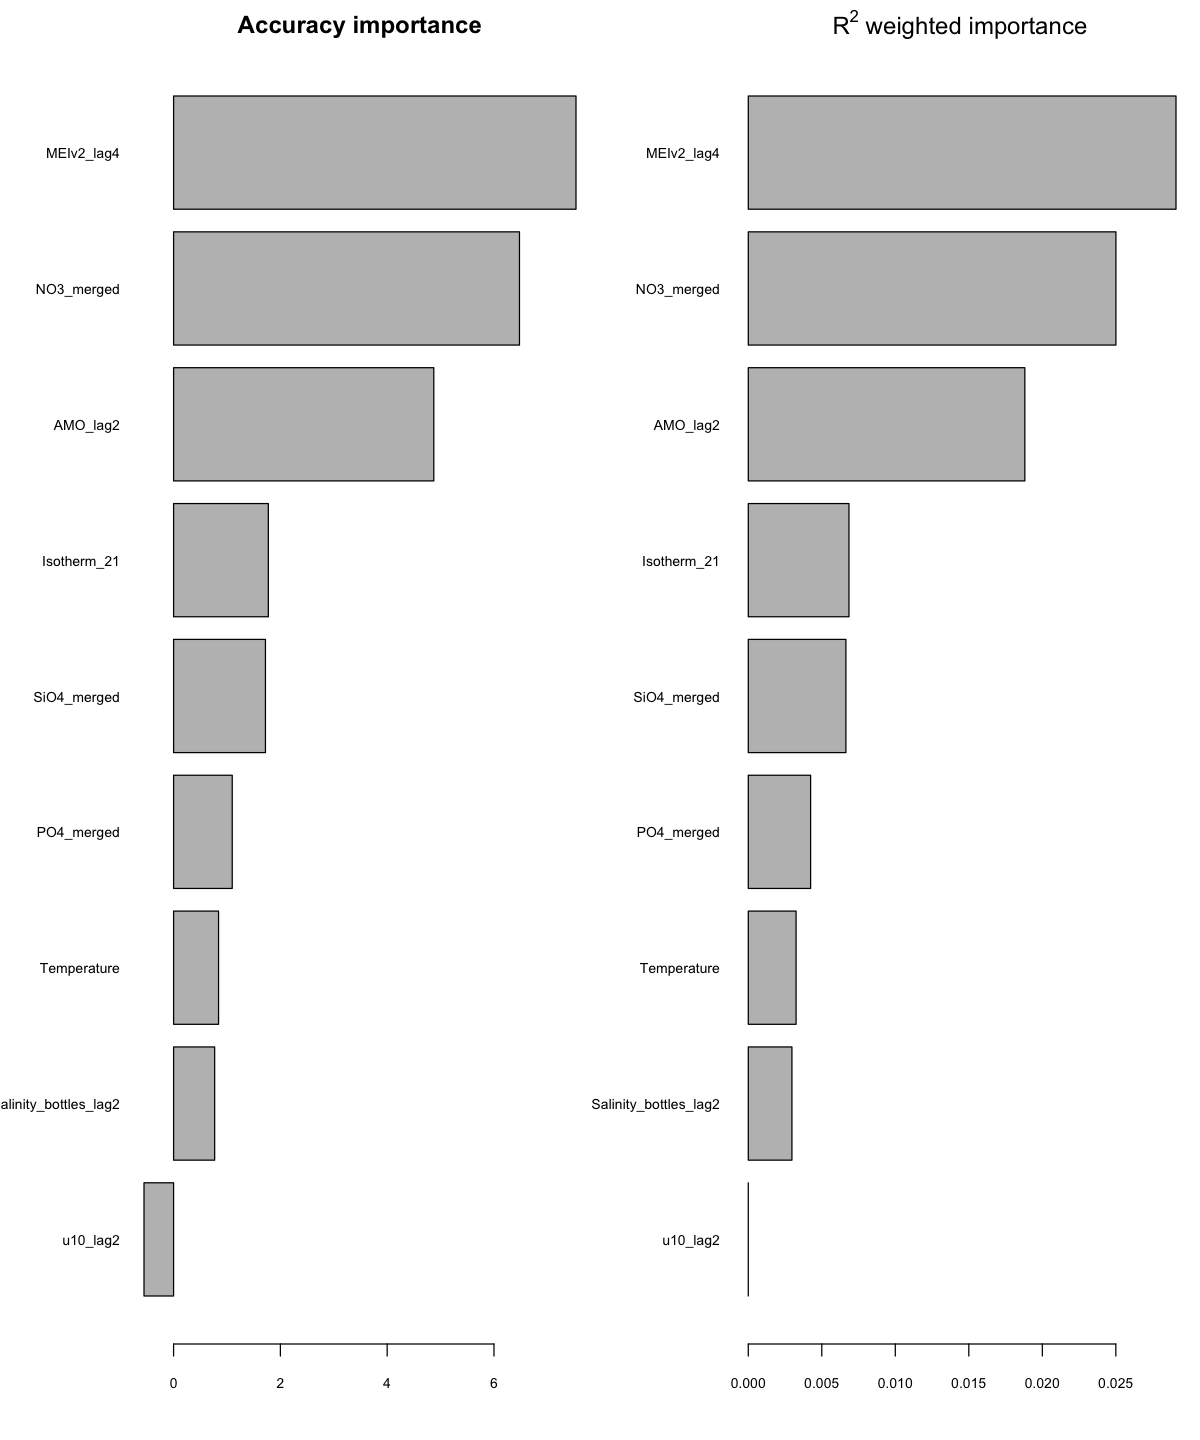

In [27]:
plot(gf, plot.type="O")

In [28]:
importance(gf)

MEIv2_lag4            NO3_merged              AMO_lag2 
          0.029092867           0.025006963           0.018812546 
          Isotherm_21           SiO4_merged            PO4_merged 
          0.006848961           0.006641209           0.004239701 
          Temperature Salinity_bottles_lag2              u10_lag2 
          0.003251527           0.002969105           0.000000000

In [29]:
most_important <- names(importance(gf))[1:4]
par(mgp = c(2, 0.75,0))

In [30]:
sum(specGF[GenusMatched$Genus])/ sum(specGF) # captures this proportion of counts!

ERROR: Error in eval(expr, envir, enclos): Objekt 'specGF' nicht gefunden


# FINAL GGPLOT2 OUTPUT

In [31]:
show.species=FALSE
show.overall=TRUE

imp.vars <- imp.var.names <- names(importance(gf))[1:9]
imp.vars

par(mfrow=rev(n2mfrow(length(imp.vars)*(show.species+show.overall))))
cols <- rainbow(length(names(gf$result)))
names(cols) <- names(gf$result)

xaxt <- if(show.overall) "n" else "s"

[1] "MEIv2_lag4"            "NO3_merged"            "AMO_lag2"             
[4] "Isotherm_21"           "SiO4_merged"           "PO4_merged"           
[7] "Temperature"           "Salinity_bottles_lag2" "u10_lag2"

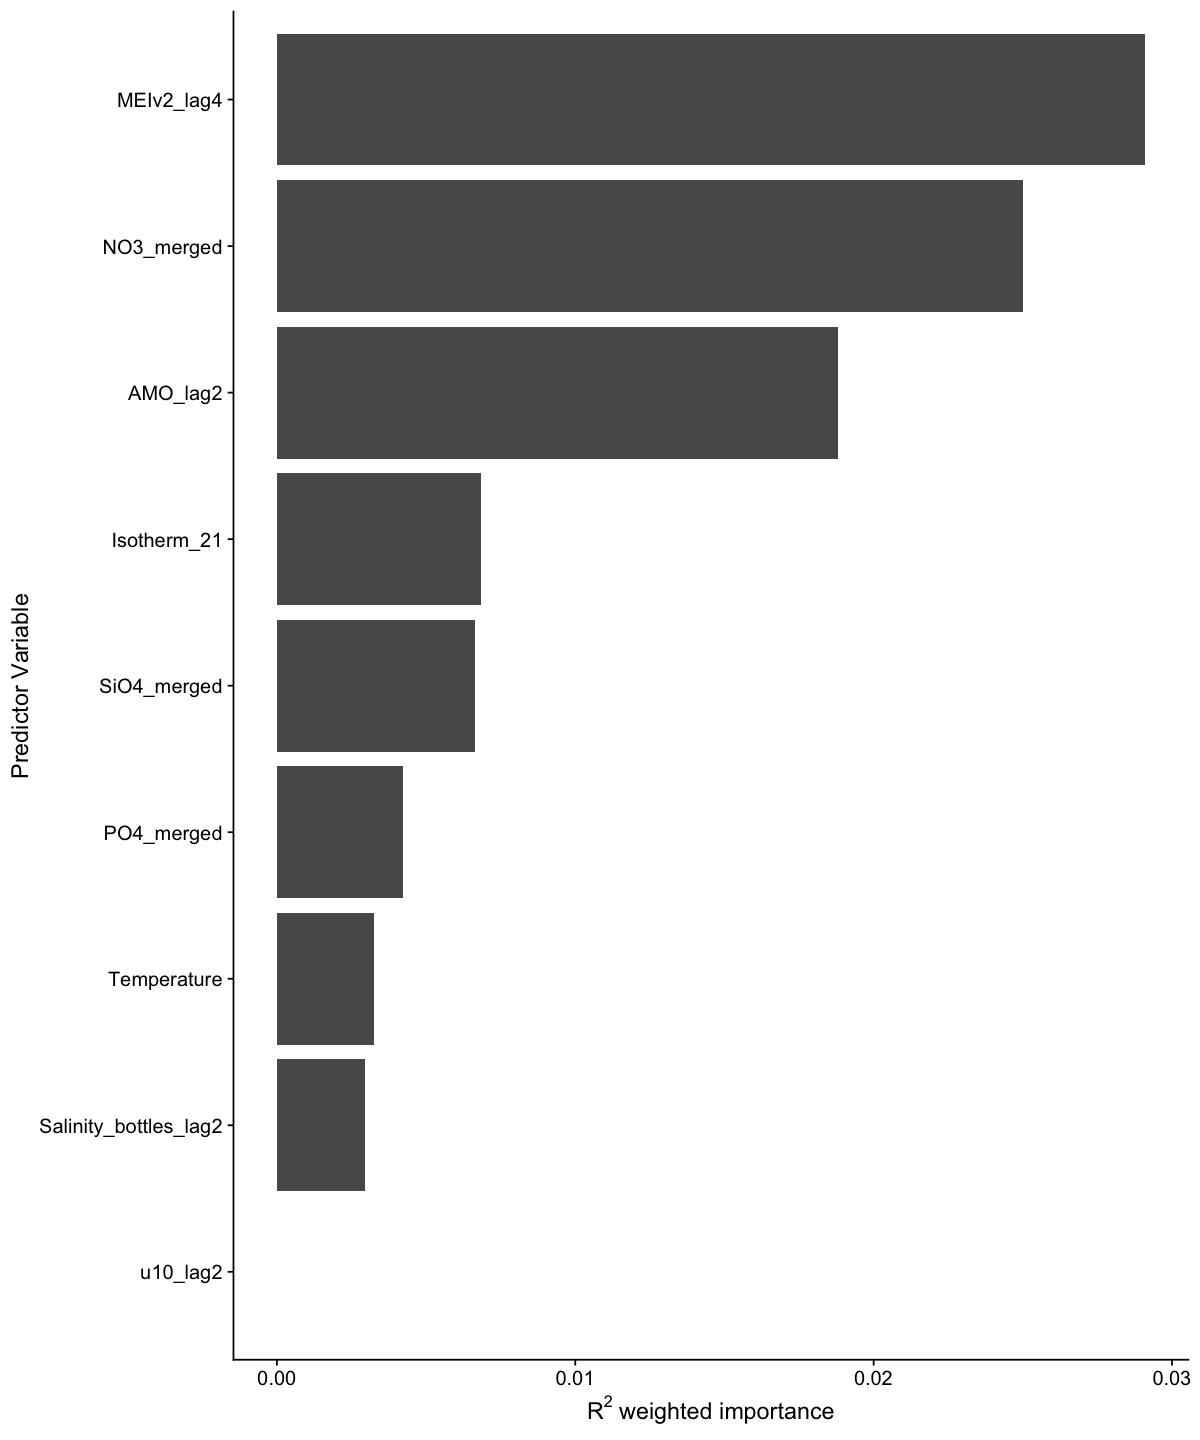

In [32]:
las = 1
cex.axis = 0.7
cex.names = cex.axis
horiz = TRUE

#imp.a <- importance(gf,"Accuracy")
imp.w <- importance(gf,"Weighted")
#o.a <- order(imp.a)
o.w <- order(imp.w)
varnames = names(imp.w[o.w])
data = imp.w[o.w]
data_df <- data.frame(var=factor(names(imp.w), levels=names(imp.w)), importance=imp.w, row.names=NULL)
title= expression(paste(R^2, " weighted importance"))

weightedImp_plot <- ggplot() + geom_bar(data=data_df[o.w,], aes(x=var, y=importance), stat="identity") +theme_cowplot()+
  coord_flip() + scale_x_discrete(limits = rev) + xlab("Predictor Variable") + ylab(title)

weightedImp_plot

In [33]:
imp.vars.names=imp.vars
common.scale=F
line.ylab=1.0
cex.legend=0.75

#species
leg.nspecies=10
leg.posn="topleft"
legend=TRUE

In [34]:

species <- names(gf$result)
species

[1] "GenusRichness"

In [35]:
linesdat = list()

for (varX in imp.vars) {
  print(varX)
  CU <- cumimp(gf, varX, "Species")
  xlim <- range(sapply(CU, "[[", "x"))
  ylim <- range(sapply(CU, "[[", "y"))

  #plot(xlim,ylim,type='n',xlab=if(show.overall) "" else imp.vars.names[imp.vars==varX],ylab="",xaxt=xaxt)
  specdat = list()
  for(species in names(CU)) {
      
      isub <- seq(1,length(CU[[species]]$x),len=pmin(500,length(CU[[species]]$x)))
      
      #print(length(CU[[species]]$x[isub]))
      #print(length(CU[[species]]$y[isub]))
        xvals = CU[[species]]$x[isub]
        yvals = CU[[species]]$y[isub]
      
        columns = c("Predictor","Species","x","y")
        testdf = data.frame(matrix(nrow=length(xvals), ncol=length(columns)))
        names(testdf) <- columns
        
        testdf$x <- xvals
        testdf$y <- yvals
        testdf$Species <- species
        testdf$Predictor <- varX
      
      specdat[[species]] = testdf
      
      #lines(CU[[species]]$x[isub],CU[[species]]$y[isub],type='s',col=cols[species])
  }

    linesdat[[varX]] = rbindlist(specdat)

    
       #added SJS 08/10/2009
  no.species<-length(names(cols))
  # only label most important species
  imp.sp <- sapply(CU, function(cu) max(cu$y))
  best <- order(-imp.sp)[1:min(leg.nspecies,length(imp.sp))]
  #if(legend)
  #    legend(x=leg.posn,legend=names(cols)[best],pch=rep(1,no.species)[best],col=cols[best],bty="n",cex=cex.legend, pt.lwd=2)
}

merged_spec_cumimp_df <- rbindlist(linesdat)

[1] "MEIv2_lag4"
[1] "NO3_merged"
[1] "AMO_lag2"
[1] "Isotherm_21"
[1] "SiO4_merged"
[1] "PO4_merged"
[1] "Temperature"
[1] "Salinity_bottles_lag2"
[1] "u10_lag2"


In [36]:
length(unique(merged_spec_cumimp_df$Species))

[1] 1

### MANUAL SPEC COLOR SCALE

In [37]:
specs = unique(merged_spec_cumimp_df$Species)

In [38]:
specs

[1] "GenusRichness"

In [39]:
# func group color scale:

GenusFuncGroup_match <- phyto_counts %>% group_by(Genus) %>% summarize(FuncGroup = first(FuncGroup))

GenusMatched <- GenusFuncGroup_match[GenusFuncGroup_match$Genus %in% specs,]

GenusMatched

Genus,FuncGroup
<chr>,<chr>


In [40]:
alphabet.colors(26)

ERROR: Error in alphabet.colors(26): konnte Funktion "alphabet.colors" nicht finden


In [41]:
library(RColorBrewer)

gg_color_hue <- function(n) {
  hues = seq(15, 375, length = n + 1)
  hcl(h = hues, l = 65, c = 100)[1:n]
}

genscolscale = brewer.pal(length(unique(GenusMatched$FuncGroup)), "Set1")
gens = unique(GenusMatched$FuncGroup)
names(genscolscale) <- gens
genscolscale

Warning message in brewer.pal(length(unique(GenusMatched$FuncGroup)), "Set1"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


<NA>      <NA>      <NA> 
"#E41A1C" "#377EB8" "#4DAF4A"

In [42]:
brewer.pal(n=5, "Set1")

[1] "#E41A1C" "#377EB8" "#4DAF4A" "#984EA3" "#FF7F00"

In [43]:
options(repr.plot.width=2, repr.plot.height=2)

TestGenScalePlot <- ggplot(data = data.frame(FuncGroup = names(genscolscale), Color=genscolscale, dat=1:5, row.names = NULL)) + 
geom_point(aes(x=FuncGroup, y=dat, col=FuncGroup)) + theme_cowplot() + scale_colour_manual(values = genscolscale)

ColScaleLegend <- get_legend(TestGenScalePlot)
plot_grid(ColScaleLegend)

ERROR: Error in data.frame(FuncGroup = names(genscolscale), Color = genscolscale, : Argumente implizieren unterschiedliche Anzahl Zeilen: 3, 5


In [44]:
GenusMatched$color <-  genscolscale[GenusMatched$FuncGroup]

In [45]:
options(repr.plot.width=6, repr.plot.height=5)
speccolscale = as.character(GenusMatched$color)
names(speccolscale) <- as.character(GenusMatched$Genus)

swatch(speccolscale)

ERROR: Error in swatch(speccolscale): konnte Funktion "swatch" nicht finden


# SPEC CUM IMP PLOT

In [46]:
str(merged_spec_cumimp_df)
merged_spec_cumimp_df$Predictor = factor(merged_spec_cumimp_df$Predictor, levels=names(imp.w))


Classes ‘data.table’ and 'data.frame':	1533 obs. of  4 variables:
 $ Predictor: chr  "MEIv2_lag4" "MEIv2_lag4" "MEIv2_lag4" "MEIv2_lag4" ...
 $ Species  : chr  "GenusRichness" "GenusRichness" "GenusRichness" "GenusRichness" ...
 $ x        : num  -2.14 -1.94 -1.92 -1.87 -1.77 ...
 $ y        : num  8.24e-06 9.26e-05 9.55e-05 1.01e-04 1.02e-04 ...
 - attr(*, ".internal.selfref")=<externalptr> 


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


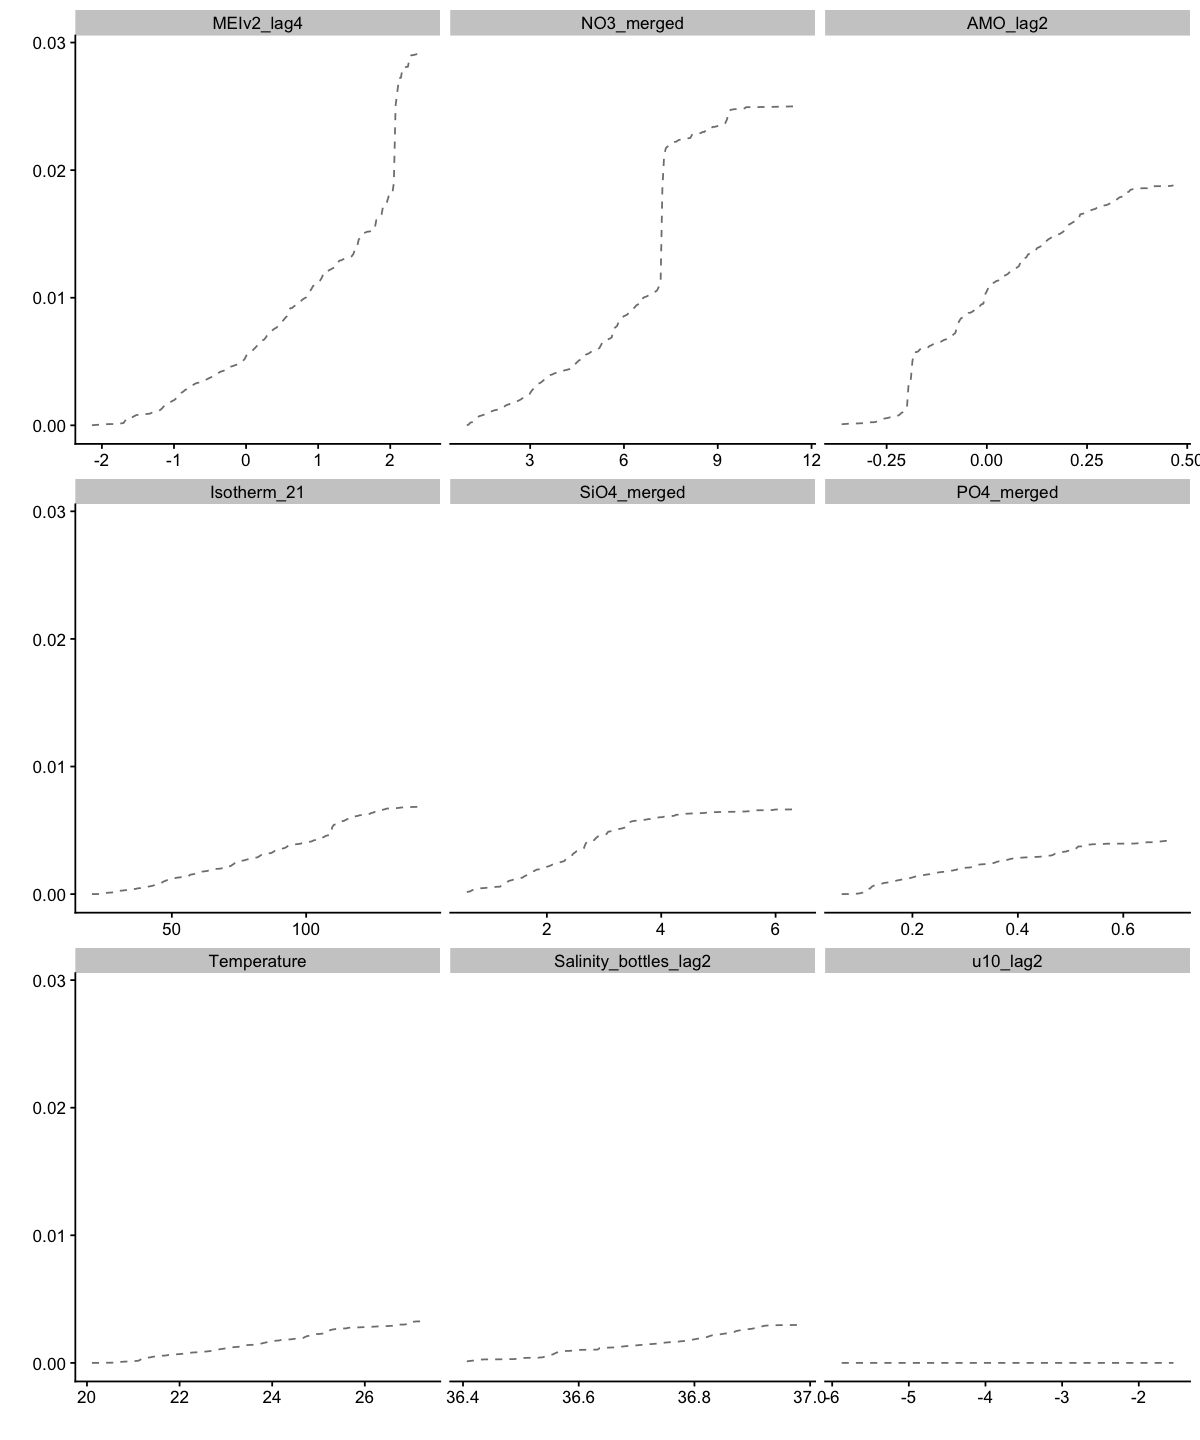

In [47]:
options(repr.plot.width=10, repr.plot.height=12)

specCumImp_Plot <- ggplot(data=merged_spec_cumimp_df)+geom_line(aes(x=x,y=y, col=Species), linetype = "dashed")+
facet_wrap(~Predictor,scales = "free_x") + xlab("") + ylab("") + theme_cowplot(font_size=12) + scale_colour_manual(values = speccolscale) + guides(color="none")
specCumImp_Plot

# Overall Cum Imp Plot

In [48]:

#
# Combine species
#
plotlist = list()
overallcumimp = list()

for (varX in imp.vars) {
  print(varX)
  CU <- cumimp(gf, varX)
  ymax <- max(CU$y)
  if (varX == imp.vars[1]){ymax1 <- ymax}
  isub <- seq(1,length(CU$x),len=pmin(500,length(CU$x)))
  #plot(CU$x[isub], CU$y[isub], type='s', ylab="",
  #  xlab=imp.vars.names[imp.vars==varX], 
  #  ylim=c(0, if(common.scale) ymax1 else ymax))
    xvals=CU$x[isub]
    yvals=CU$y[isub]
    
    columns = c("Predictor","Species","x","y")
    testdf = data.frame(matrix(nrow=length(xvals), ncol=length(columns)))
    names(testdf) <- columns
        
    testdf$x <- CU$x[isub]
    testdf$y <- CU$y[isub]
    testdf$Species <- "overall"
    testdf$Predictor <- varX
      
    overallcumimp[[varX]] = testdf
         
}

OVCumImpDat <- rbindlist(overallcumimp)
#mtext("Cumulative importance",side=2,line=line.ylab,outer=TRUE)


OVCumImpDat$Predictor = factor(OVCumImpDat$Predictor, levels=names(imp.w))

[1] "MEIv2_lag4"
[1] "NO3_merged"
[1] "AMO_lag2"
[1] "Isotherm_21"
[1] "SiO4_merged"
[1] "PO4_merged"
[1] "Temperature"
[1] "Salinity_bottles_lag2"
[1] "u10_lag2"


In [49]:
# convert density to its inverse
inverse <- function(dens) {dens$y <- 1/dens$y; dens}

# crude integral
crude.integrate <- function(f) sum(f$y)*diff(f$x)[1]

# normalize f(x) to f(x)/fbar
normalize <- function(f) {
    integral <- try(integrate(approxfun(f,rule=2),lower=min(f$x),upper=max(f$x))$value)
    if (class(integral)=="try-error") integral <- crude.integrate(f)
    f$y <- f$y/integral*diff(range(f$x)); 
    f
}

getCU <- function(importance.df, Rsq, predictor) {
    if (nrow(importance.df) == 0) {
      return( list(x=0, y=0))
    }
    agg <- with(importance.df, agg.sum(improve.norm, list(split), sort.it=TRUE))
    cum.split <- agg[,1]
    height <- agg[,2]

    if (standardize & standardize_after) # crucial to normalize this case
      dinv <- normalize(inverse(x$dens[[predictor]]))
    else dinv <- inverse(x$dens[[predictor]]) # 
    dinv.vals <- approx(dinv$x, dinv$y, cum.split, rule=2)$y
    if (any(bad <- is.na(height))) {
      cum.split <- cum.split[!bad]
      height <- height[!bad]
      dinv.vals <- dinv.vals[!bad]
    }
    if (standardize & !standardize_after) height <- height * dinv.vals
    height <- height/sum(height)*Rsq
    if (standardize & standardize_after) height <- height * dinv.vals
    res <- list(x=cum.split, y=cumsum(height))
}

# TRY AND GET PROPER GENUS CUM IMP BELOW HERE

In [50]:

unique(GenusMatched$FuncGroup)

character(0)

In [51]:
CU_test <- cumimp(gf, "AMO_lag2", "Species")
xlim_test <- range(sapply(CU_test, "[[", "x"))
ylim_test <- range(sapply(CU_test, "[[", "y"))

unique(GenusMatched$FuncGroup)

Genus <- GenusMatched %>% filter(FuncGroup=="Dinoflagellata") %>% pull(Genus)

Genus 
#Gen_CU <- getCU(subset(importance.df, spec %in% Genus | var == varX), mean(x$imp.rsq[varX, Genus]), varX)
#CU_test[Genus]

#get importance statistic
importance.df <- gf$res[gf$res$var=="AMO_lag2",]

character(0)

character(0)

In [52]:
agg <- with(subset(importance.df, spec %in% Genus), agg.sum(improve.norm, list(split), sort.it=TRUE))
cum.split <- agg[,1]
height <- agg[,2]

dinv <- inverse(x$dens[["AMO_lag2"]])

dinv.vals <- approx(dinv$x, dinv$y, cum.split, rule=2)$y

Rsq = mean(x$imp.rsq["AMO_lag2", Genus])
           
#
height <- height * dinv.vals
#normalize
height <- height/sum(height)*Rsq

ERROR: Error in agg.sum(improve.norm, list(split), sort.it = TRUE): konnte Funktion "agg.sum" nicht finden


In [53]:
plot(cum.split, cumsum(height))

ERROR: Error in eval(expr, envir, enclos): Objekt 'cum.split' nicht gefunden


In [54]:
plot(cum.split, cumsum(height))

ERROR: Error in eval(expr, envir, enclos): Objekt 'cum.split' nicht gefunden


In [55]:
agg <- with(importance.df, agg.sum(improve.norm, list(split), sort.it=TRUE))
cum.split <- agg[,1]
height <- agg[,2]



ERROR: Error in agg.sum(improve.norm, list(split), sort.it = TRUE): konnte Funktion "agg.sum" nicht finden


In [56]:
dinvs <- inverse(x$dens[["AMO_lag2"]])


ERROR: Error in eval(expr, envir, enclos): Objekt 'x' nicht gefunden


In [57]:
linesdat = list()

for (varX in imp.vars) {
  print(varX)
  CU <- cumimp(gf, varX, "Species")
  xlim <- range(sapply(CU, "[[", "x"))
  ylim <- range(sapply(CU, "[[", "y"))

  #plot(xlim,ylim,type='n',xlab=if(show.overall) "" else imp.vars.names[imp.vars==varX],ylab="",xaxt=xaxt)
  specdat = list()
  for(species in names(CU)) {
      
      isub <- seq(1,length(CU[[species]]$x),len=pmin(500,length(CU[[species]]$x)))
      
      #print(length(CU[[species]]$x[isub]))
      #print(length(CU[[species]]$y[isub]))
        xvals = CU[[species]]$x[isub]
        yvals = CU[[species]]$y[isub]
      
        columns = c("Predictor","Species","x","y")
        testdf = data.frame(matrix(nrow=length(xvals), ncol=length(columns)))
        names(testdf) <- columns
        
        testdf$x <- xvals
        testdf$y <- yvals
        testdf$Species <- species
        testdf$Predictor <- varX
      
      specdat[[species]] = testdf
      
      #lines(CU[[species]]$x[isub],CU[[species]]$y[isub],type='s',col=cols[species])
  }

    linesdat[[varX]] = rbindlist(specdat)

    
       #added SJS 08/10/2009
  no.species<-length(names(cols))
  # only label most important species
  imp.sp <- sapply(CU, function(cu) max(cu$y))
  best <- order(-imp.sp)[1:min(leg.nspecies,length(imp.sp))]
  #if(legend)
  #    legend(x=leg.posn,legend=names(cols)[best],pch=rep(1,no.species)[best],col=cols[best],bty="n",cex=cex.legend, pt.lwd=2)
}

[1] "MEIv2_lag4"
[1] "NO3_merged"
[1] "AMO_lag2"
[1] "Isotherm_21"
[1] "SiO4_merged"
[1] "PO4_merged"
[1] "Temperature"
[1] "Salinity_bottles_lag2"
[1] "u10_lag2"


# END OF EXPERIMENTAL PHASE

In [58]:
namenames <- function(x) structure(x,names=x)

`agg.sum` <- function(x, by, sort.it = F)
{
	if(!is.data.frame(by))
		by <- data.frame(by)
	if(sort.it) {
		ord <- do.call("order", unname(by))
		x <- x[ord]
		by <- by[ord,  , drop=F]
	}
	logical.diff <- function(group)
	group[-1] != group[ - length(group)]
	change <- logical.diff(by[[1]])
	for(i in seq(along = by)[-1])
		change <- change | logical.diff(by[[i]])
  by <- by[c(T, change),  , drop = F]
	by$x <- diff(c(0, cumsum(x)[c(change, T)]))
	by
}

In [59]:
x <- gf
option=2
standardize=TRUE
standardize_after=FALSE

linesdat_genus = list()

for (varX in imp.vars) {
  #print(varX)
  CU <- cumimp(gf, varX, "Species")
  xlim <- range(sapply(CU, "[[", "x"))
  ylim <- range(sapply(CU, "[[", "y"))
    
  importance.df <- gf$res[gf$res$var==varX,]

  #plot(xlim,ylim,type='n',xlab=if(show.overall) "" else imp.vars.names[imp.vars==varX],ylab="",xaxt=xaxt)
  FGdat = list()
  for(funcgroup in unique(GenusMatched$FuncGroup)) {

      Genus <- GenusMatched %>% filter(FuncGroup==funcgroup) %>% pull(Genus)

      
      Gen_CU <- getCU(subset(importance.df, spec %in% Genus), mean(x$imp.rsq[varX, Genus]), varX)
      
      isub <- seq(1,length(Gen_CU$x),len=pmin(500,length(Gen_CU$x)))
      
      #print(length(CU[[species]]$y[isub]))
        xvals = Gen_CU$x[isub]
        yvals = Gen_CU$y[isub]
      
        columns = c("Predictor","FuncGroup","x","y")
        testdf = data.frame(matrix(nrow=length(xvals), ncol=length(columns)))
        names(testdf) <- columns
        
        testdf$x <- xvals
        testdf$y <- yvals
        testdf$FuncGroup <- funcgroup
        testdf$Predictor <- varX
      
      FGdat[[funcgroup]] = testdf
      
      #lines(CU[[species]]$x[isub],CU[[species]]$y[isub],type='s',col=cols[species])
  }

    linesdat_genus[[varX]] = rbindlist(FGdat)

    
       #added SJS 08/10/2009
  #no.species<-length(names(cols))
  # only label most important species
  #imp.sp <- sapply(CU, function(cu) max(cu$y))
  #best <- order(-imp.sp)[1:min(leg.nspecies,length(imp.sp))]
  #if(legend)
  #    legend(x=leg.posn,legend=names(cols)[best],pch=rep(1,no.species)[best],col=cols[best],bty="n",cex=cex.legend, pt.lwd=2)
}

merged_genus_cumimp_df <- rbindlist(linesdat_genus)

In [60]:
head(OVCumImpDat)

Predictor,Species,x,y
<fct>,<chr>,<dbl>,<dbl>
MEIv2_lag4,overall,-2.13825,8.243292e-06
MEIv2_lag4,overall,-1.94345,9.255437e-05
MEIv2_lag4,overall,-1.91910,9.545121e-05
MEIv2_lag4,overall,-1.87040,1.011891e-04
MEIv2_lag4,overall,-1.77300,1.021632e-04
MEIv2_lag4,overall,-1.72430,1.608396e-04


In [61]:
levels(OVCumImpDat$Predictor)

[1] "MEIv2_lag4"            "NO3_merged"            "AMO_lag2"             
[4] "Isotherm_21"           "SiO4_merged"           "PO4_merged"           
[7] "Temperature"           "Salinity_bottles_lag2" "u10_lag2"

In [62]:
str(merged_genus_cumimp_df$Predictor)
str(OVCumImpDat$Predictor)

merged_genus_cumimp_df$Predictor <- factor(merged_genus_cumimp_df$Predictor, levels=levels(OVCumImpDat$Predictor))

 NULL
 Factor w/ 9 levels "MEIv2_lag4","NO3_merged",..: 1 1 1 1 1 1 1 1 1 1 ...


In [63]:
options(repr.plot.width=10, repr.plot.height=12)

filt_vars = c("AMO_lag2", "MEIv2_lag4", "NO3_merged", "Temperature")
# %>% filter(Predictor %in% filt_vars)

overallCumImp_Plot <- ggplot(data=merged_genus_cumimp_df%>% filter(Predictor %in% filt_vars)) + geom_line(aes(x=x,y=y, col=FuncGroup), alpha=1, linewidth=1.1)+
geom_line(data=OVCumImpDat%>% filter(Predictor %in% filt_vars), aes(x=x,y=y), linewidth=1.5, , linetype = "22")+
facet_wrap(~Predictor,scales = "free_x") + xlab("Predictor") + ylab("Cumulative Importance") + theme_cowplot(font_size=20) + scale_colour_manual(values = genscolscale) + guides(color="none")
overallCumImp_Plot

ERROR while rich displaying an object: Error in `geom_line()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! Objekt 'y' nicht gefunden

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)

## Species Imp Plot

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


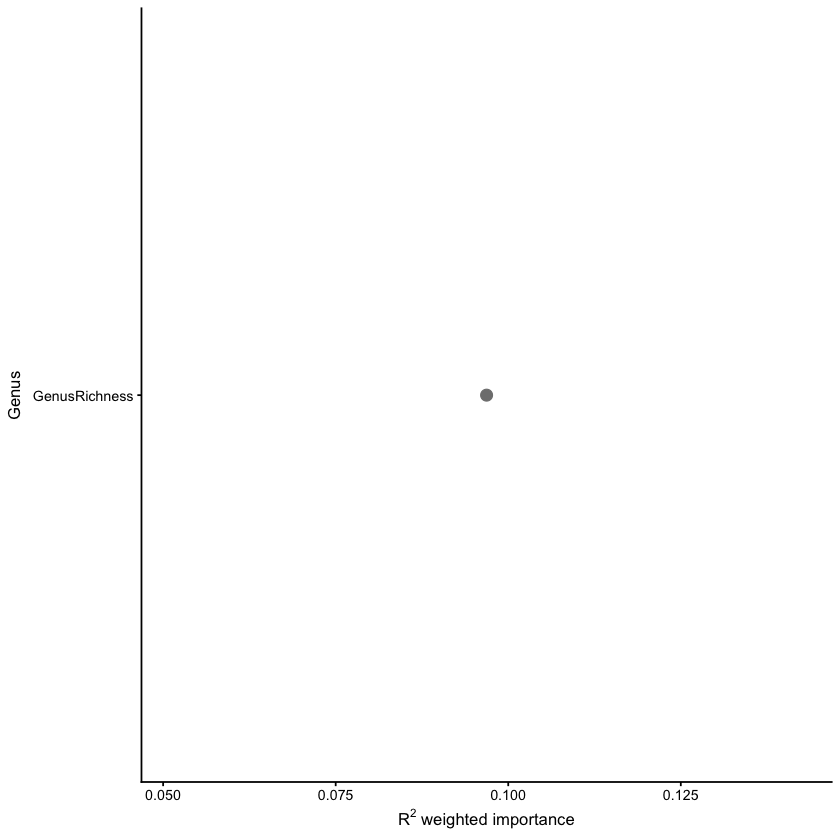

In [64]:
options(repr.plot.width=7, repr.plot.height=7)

perf <- importance(gf, type="Species") 
#perf

o.s <- order(perf)
specnames = names(perf[o.s])
speccdata = perf[o.s]

speccdata_df <- data.frame(Genus=factor(specnames, levels=specnames), importance=speccdata, row.names=NULL)

n <- length(perf)
title= expression(paste(R^2, " weighted importance"))

specImp_plot <- ggplot(data=speccdata_df) + geom_point(aes(x=Genus,y=importance, col=Genus), size=3) + theme_cowplot(font_size=10) + 
    coord_flip() + ylab(title) + scale_colour_manual(values = speccolscale) + guides(color="none")


specImp_plot 

In [65]:
options(repr.plot.width=12, repr.plot.height=16)

left_column = overallCumImp_Plot
right_column = plot_grid(weightedImp_plot, specImp_plot,ColScaleLegend, ncol=3, rel_widths=c(1,1,0.1))

GF_output_plot1 <- plot_grid(right_column, left_column, ncol=1, rel_heights = c(1.8,2))

GF_output_plot1
ggsave("GF_output_plot3_new.pdf",GF_output_plot1, width=12, height=16)

ERROR: Error in eval(expr, envir, enclos): Objekt 'ColScaleLegend' nicht gefunden
